BrainTumorDetection/

│

├── dataset/

│     ├── Training/

│     ├── Testing/

│

├── notebooks/

│

├── models/

│

├── app.py

├── train.py

├── predict.py

├── preprocess.py

├── requirements.txt

├── README.md

└── images/

**Import Libraries**

In [1]:
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Conv2D

from tensorflow.keras.layers import MaxPooling2D

from tensorflow.keras.layers import Flatten

from tensorflow.keras.layers import Dense

from tensorflow.keras.layers import Dropout

import matplotlib.pyplot as plt

import numpy as np

**Data Preprocessing**

In [2]:
# Image Augmentation
train_datagen = ImageDataGenerator(

    rescale=1./255,

    rotation_range=20,

    zoom_range=0.2,

    horizontal_flip=True,

    validation_split=0.2

)


In [4]:
import os

print(os.getcwd())

/Users/udaipratapsingh/Documents/PROJECTS/Brain Tumor/notebooks


**Define Paths**

In [5]:
train_path = "../dataset/Training"
test_path = "../dataset/Testing"

**Create ImageDataGenerator**

In [6]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

**Training Generator**

In [7]:
train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical",
    subset="training"
)

Found 2297 images belonging to 4 classes.


**Validation Generator**

In [8]:
validation_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical",
    subset="validation"
)

Found 573 images belonging to 4 classes.


**Test Generator (used after training)**

In [9]:
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)

Found 394 images belonging to 4 classes.


In [10]:
import os

print(os.listdir("/Users/udaipratapsingh/Documents/PROJECTS/Brain Tumor/notebooks"))
print(os.listdir(train_path))

['brain_tumor_project.ipynb']
['no_tumor', '.DS_Store', 'meningioma_tumor', 'glioma_tumor', 'pituitary_tumor']


**Load Dataset**

In [11]:
train_generator = train_datagen.flow_from_directory(

    train_path,

    target_size=(224,224),

    batch_size=32,

    class_mode="categorical",

    subset="training"

)

Found 2297 images belonging to 4 classes.


In [12]:
validation_generator = train_datagen.flow_from_directory(

    test_path,

    target_size=(224,224),

    batch_size=32,

    class_mode="categorical",

    subset="validation"

)

Found 78 images belonging to 4 classes.


**Check Classes**

In [13]:
print(train_generator.class_indices)

{'glioma_tumor': 0, 'meningioma_tumor': 1, 'no_tumor': 2, 'pituitary_tumor': 3}


**CNN Model**

In [14]:
# Build CNN
model = Sequential()

model.add(

Conv2D(

32,

(3,3),

activation="relu",

input_shape=(224,224,3)

)

)

model.add(MaxPooling2D(pool_size=(2,2)))

model.add(

Conv2D(

64,

(3,3),

activation="relu"

)

)

model.add(MaxPooling2D(pool_size=(2,2)))

model.add(

Conv2D(

128,

(3,3),

activation="relu"

)

)

model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Flatten())

model.add(Dense(128,activation="relu"))

model.add(Dropout(0.5))

model.add(Dense(4,activation="softmax"))

/opt/anaconda3/envs/ml_env/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


**Model Summary**

In [15]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,476 (42.61 MB)

 Trainable params: 11,169,476 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

**Model Compilation**

In [16]:
# Compile
model.compile(

optimizer="adam",

loss="categorical_crossentropy",

metrics=["accuracy"]

)

**Model Training**

In [17]:
# Train
history = model.fit(

train_generator,

epochs=10,

validation_data=validation_generator

)

Epoch 1/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 119s 2s/step - accuracy: 0.4562 - loss: 1.2293 - val_accuracy: 0.2564 - val_loss: 1.6850
Epoch 2/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 104s 1s/step - accuracy: 0.5895 - loss: 0.9476 - val_accuracy: 0.2692 - val_loss: 2.6091
Epoch 3/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 112s 2s/step - accuracy: 0.6587 - loss: 0.7952 - val_accuracy: 0.3205 - val_loss: 2.7888
Epoch 4/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 616s 9s/step - accuracy: 0.7057 - loss: 0.7162 - val_accuracy: 0.3462 - val_loss: 2.8097
Epoch 5/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 5540s 78s/step - accuracy: 0.7131 - loss: 0.6745 - val_accuracy: 0.2949 - val_loss: 2.6577
Epoch 6/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 3194s 32s/step - accuracy: 0.7196 - loss: 0.6615 - val_accuracy: 0.2821 - val_loss: 2.8569
Epoch 7/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 114s 2s/step - accuracy: 0.7479 - loss: 0.6023 - val_accuracy: 0.3205 - val_loss: 3.4031
Epoch 8/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 109s 2s/step - accuracy: 0.7579 - loss: 0.5999 - val_accuracy: 0.3846

**Performance**

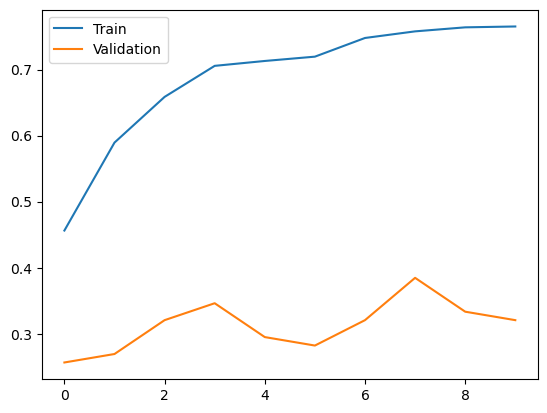

In [18]:
# Plot Accuracy
plt.plot(history.history["accuracy"])

plt.plot(history.history["val_accuracy"])

plt.legend(["Train","Validation"])

plt.show()

**Plot Loss**

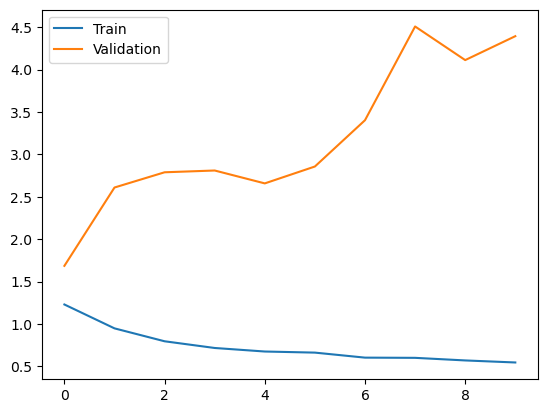

In [19]:
plt.plot(history.history["loss"])

plt.plot(history.history["val_loss"])

plt.legend(["Train","Validation"])

plt.show()

**Evaluate**

In [20]:
loss,accuracy=model.evaluate(validation_generator)

print(accuracy)

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 379ms/step - accuracy: 0.3846 - loss: 4.1922
0.38461539149284363


**Save Model**

In [21]:
model.save("brain_tumor_model.keras")

**Prediction**

In [22]:
# Load Model
from tensorflow.keras.models import load_model

model=load_model("brain_tumor_model.keras")

**Read Image**

In [24]:
from tensorflow.keras.preprocessing import image

img=image.load_img(

"/Users/udaipratapsingh/Documents/PROJECTS/Brain Tumor/images/PHOTO-2026-07-23-15-52-33.jpg",

target_size=(224,224)

)

img=image.img_to_array(img)

img=img/255

img=np.expand_dims(img,axis=0)

**Prediction**

In [25]:
prediction=model.predict(img)

classes=["Glioma",

"Meningioma",

"No Tumor",

"Pituitary"]

print(classes[np.argmax(prediction)])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step
No Tumor


**Upload MRI**

In [26]:
import streamlit as st

uploaded_file = st.file_uploader(

"Upload MRI",

type=["jpg","png","jpeg"]

)

2026-07-23 19:15:16.730 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-23 19:15:16.731 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-23 19:15:16.731 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-23 19:15:16.739 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-23 19:15:16.793 
  command:

    streamlit run /opt/anaconda3/envs/ml_env/lib/python3.10/site-packages/ipykernel_launcher.py [ARGUMENTS]
2026-07-23 19:15:16.794 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-23 19:15:16.794 Thread

**Display Image**

**Predict**

In [27]:
if st.button("Predict"):

    prediction=model.predict(img)

    st.success(

    classes[np.argmax(prediction)]

    )

2026-07-23 19:15:23.192 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-23 19:15:23.193 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-23 19:15:23.195 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-23 19:15:23.196 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-23 19:15:23.197 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-23 19:15:23.197 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


**Confidence**

In [28]:
confidence=np.max(prediction)*100

st.write(

f"Confidence : {confidence:.2f}%"

)

2026-07-23 19:15:25.566 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-23 19:15:25.567 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-23 19:15:25.568 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
